# PhysioNet 2012 데이터 품질 EDA

## Goal

공식 Set A 원본의 구조, 불규칙한 측정 횟수, missing sentinel과 patient-level 변환 결과를 Pandas로 확인합니다. Feature 선택이나 모델 튜닝은 이 실습의 범위가 아닙니다.

## Setup

### 1. 경로와 계약 불러오기

이 Notebook은 repository root에서 실행합니다. 원본 출처와 집계 규칙은 versioned YAML을 기준으로 읽습니다.

In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from aiqa_data.adapters import (
    PhysioNetRecordRepository,
    load_aggregation_plan,
    load_source_contract,
)
from aiqa_data.adapters.physionet import parse_record
from aiqa_data.application import profile_raw_records

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file() and (candidate / "configs").is_dir()
)
SOURCE_CONTRACT = ROOT / "configs/contracts/physionet-record.yaml"
AGGREGATION_CONFIG = ROOT / "configs/data/aggregation.yaml"
PROCESSED_DATA = ROOT / "data/processed/physionet-2012/patient-features.csv"
V2_SPLIT_MANIFEST = ROOT / "data/splits/physionet-2012/revisions/v2/split-manifest.csv"

source = load_source_contract(SOURCE_CONTRACT)
plan = load_aggregation_plan(AGGREGATION_CONFIG)
print(
    {"dataset": "PhysioNet 2012 Set A", "available_features": len(plan.feature_names)}
)

{'dataset': 'PhysioNet 2012 Set A', 'available_features': 133}


## Steps

### 2. 환자 record 하나 살펴보기

각 파일은 한 ICU stay이며 `Time`, `Parameter`, `Value` 행으로 구성됩니다. `-1`은 실제 측정값이 아니라 missing sentinel입니다.

In [2]:
sample_path = ROOT / source.records_dir / "132539.txt"
sample_frame = pd.read_csv(sample_path)
sample_frame.head(12)

,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
5,00:00,Weight,-1.00
6,00:07,GCS,15.00
7,00:07,HR,73.00
8,00:07,NIDiasABP,65.00
9,00:07,NIMAP,92.33


In [3]:
sample_record = parse_record(
    sample_path, max_minute=source.observation_window_hours * 60
)
sample_summary = {
    "record_id": sample_record.record_id,
    "measurement_rows": len(sample_record.observations),
    "parameters": len({item.parameter for item in sample_record.observations}),
    "sentinels": sum(
        item.value == plan.missing_sentinel for item in sample_record.observations
    ),
    "maximum_minute": max(item.minute for item in sample_record.observations),
}
sample_summary

{'record_id': 132539,
 'measurement_rows': 272,
 'parameters': 23,
 'sentinels': 2,
 'maximum_minute': 2857}

### 3. 전체 raw record의 측정 구조 확인

4,000개 파일을 한 번씩 읽어 환자별 측정 행 수, parameter 수, sentinel 수와 시간 범위를 요약합니다.

In [4]:
repository = PhysioNetRecordRepository(
    ROOT / source.records_dir,
    source.expected_record_count,
    source.observation_window_hours,
)
raw_profile = pd.DataFrame(
    asdict(item) for item in profile_raw_records(repository, plan.missing_sentinel)
)
raw_profile.describe().round(2)

,record_id,observation_count,parameter_count,sentinel_count,min_minute,max_minute
count,4000.00,4000.00,4000.00,4000.00,4000.0,4000.00
mean,137605.12,438.50,30.75,0.56,0.0,2831.54
std,2923.61,129.05,4.71,0.64,0.0,154.71
min,132539.00,5.00,5.00,0.00,0.0,0.00
25%,135075.75,359.00,28.00,0.00,0.0,2834.00
50%,137592.50,427.00,31.00,0.00,0.0,2853.00
75%,140100.25,511.00,34.00,1.00,0.0,2868.00
max,142673.00,1501.00,39.00,3.00,0.0,2880.00


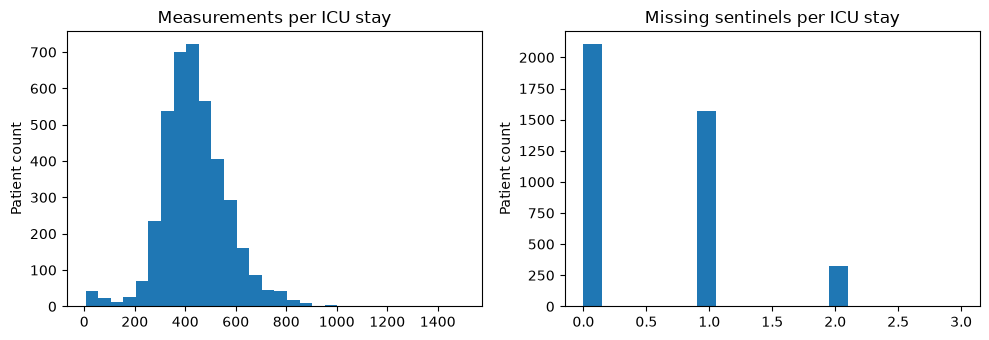

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
raw_profile["observation_count"].plot.hist(
    bins=30, ax=axes[0], title="Measurements per ICU stay"
)
raw_profile["sentinel_count"].plot.hist(
    bins=20, ax=axes[1], title="Missing sentinels per ICU stay"
)
for axis in axes:
    axis.set_ylabel("Patient count")
plt.tight_layout()

### 4. Patient-level 변환 결과 확인

DVC가 생성한 patient-level table과 V2 split revision manifest를 확인합니다. V2는 parent split의 400개 operational cohort를 새 sealed test로 고정하고, parent test 일부를 train으로 이동한 revision입니다. Null 값은 sklearn pipeline에서 train 기준으로 처리하고, `__missing` 컬럼은 원본 측정 부재를 명시적으로 보존합니다.

In [6]:
patient_features = pd.read_csv(PROCESSED_DATA)
splits = pd.read_csv(V2_SPLIT_MANIFEST)
print(
    {
        "rows": len(patient_features),
        "available_features": len(patient_features.columns) - 2,
        "deaths": int(patient_features["target"].sum()),
    }
)
role_counts = splits["role"].value_counts().sort_index()
assert role_counts.to_dict() == {
    "operational": 100,
    "test": 400,
    "train": 2900,
    "valid": 600,
}
role_counts

{'rows': 4000, 'available_features': 133, 'deaths': 554}


role
operational     100
test            400
train          2900
valid           600
Name: count, dtype: int64

In [7]:
missing_columns = [
    column for column in patient_features if column.endswith("__missing")
]
missing_rates = (
    patient_features[missing_columns]
    .mean()
    .sort_values(ascending=False)
    .rename_axis("feature")
    .to_frame("missing_rate")
)
missing_rates.head(10)

,missing_rate
feature,
height__missing,0.47350
lactate__missing,0.45425
mechanical_ventilation__missing,0.36775
fio2__missing,0.32075
pao2__missing,0.24425
ph__missing,0.24000
non_invasive_map__missing,0.12975
non_invasive_diastolic_bp__missing,0.12925
non_invasive_systolic_bp__missing,0.12675


### 5. 자동 검증 evidence 읽기

EDA에서 관찰한 구조 규칙은 Great Expectations checkpoint로 자동화됩니다. 이 표는
실습에서 생성한 runtime evidence를 읽으며, 원본의 missing 자체가 아니라 구조 계약의
성공 여부를 판단합니다.

In [8]:
import json

QUALITY_SUMMARY = ROOT / "artifacts/data-quality/great-expectations/validation-summary.json"
if QUALITY_SUMMARY.exists():
    quality_document = json.loads(QUALITY_SUMMARY.read_text(encoding="utf-8"))
    validation_evidence = pd.DataFrame(
        [
            {
                "checkpoint": checkpoint,
                "success": quality_document[checkpoint]["success"],
                "expectations": quality_document[checkpoint]["statistics"][
                    "evaluated_expectations"
                ],
                "success_percent": quality_document[checkpoint]["statistics"][
                    "success_percent"
                ],
            }
            for checkpoint in ("raw_ingestion", "processed_readiness")
        ]
    ).set_index("checkpoint")
    assert validation_evidence["success"].all()
else:
    validation_evidence = pd.DataFrame(
        [{"next_action": "Run `uv run python scripts/validate_data.py` first."}]
    )
validation_evidence

,success,expectations,success_percent
checkpoint,,,
raw_ingestion,True,8,100.0
processed_readiness,True,57,100.0


## Checks

### 5. 데이터 계약 확인

아래 assertion은 모델 성능과 무관한 source/processed 구조 계약만 확인합니다.

In [9]:
assert len(raw_profile) == 4000
assert raw_profile["record_id"].is_unique
assert raw_profile["max_minute"].max() <= 48 * 60
assert len(patient_features) == 4000
assert len(patient_features.columns) - 2 == 133
assert patient_features["record_id"].is_unique
assert int(patient_features["target"].sum()) == 554
assert set(splits["role"]) == {"train", "valid", "test", "operational"}
assert role_counts.to_dict() == {"operational": 100, "test": 400, "train": 2900, "valid": 600}
print("All EDA contract checks passed.")

All EDA contract checks passed.


## Next Steps

- 원본에는 환자별 측정 빈도 차이와 실제 missing sentinel이 존재합니다.
- Patient-level table은 4,000행과 133개 available feature를 재현합니다.
- 결측률은 변수별로 크게 다르므로 삭제보다 명시적 missing indicator와 train-fitted imputation을 사용합니다.
- 다음 실습에서는 같은 구조 검사를 Great Expectations checkpoint로 자동화합니다.